In [5]:
import torch 
from torch.utils.data import Dataset, DataLoader
from pyteomics import mgf
import numpy as np
import logging
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch import optim
import networkx as nx
from collections import deque
from matplotlib import pyplot as plt

from sklearn.metrics import (
    adjusted_mutual_info_score as AMI,
    adjusted_rand_score as ARI,
)
import random
import pandas as pd



# Load feature data

<!-- # model input data preparation -->

In [ ]:
# processed_features = pd.read_hdf("./peptdeepwork/processed_features.h5", key="features")
# processed_features.dropna()


In [6]:
# filePath = "./peptdeepwork/feature_vectors_02.hdf"
filePath = "./peptdeepwork/processed_features_01.h5"
feature_vectors = pd.read_hdf( filePath, key="features").dropna()  
processed_features = feature_vectors
processed_features


,charge,precursor_mz,rt_pred,mobility_pred,frag_mz_1,frag_mz_2,frag_mz_3,frag_mz_4,frag_mz_5,frag_mz_6,...,frag_intensity_16,frag_intensity_17,frag_intensity_18,frag_intensity_19,frag_intensity_20,frag_intensity_21,frag_intensity_22,frag_intensity_23,frag_intensity_24,frag_intensity_25
18080635323514663207,2,804.918724,0.866920,1.121280,1265.655884,1250.597290,1152.571777,1135.570435,1064.533203,1021.531311,...,0.000000,0.133576,0.000000,0.517990,0.145572,1.000000,0.000000,0.314286,0.000000,0.000000
14669807044004538680,2,804.443223,0.439486,1.115837,1508.810791,1461.773682,1380.715820,1314.705200,1279.668091,1213.657593,...,0.458418,0.993758,0.445864,0.449113,0.987423,0.450479,0.982555,0.447263,0.993822,0.451014
584780176198780664,4,366.939525,0.396560,0.692501,1203.603760,1104.535400,991.451294,920.414185,833.382202,719.339233,...,0.000000,0.000000,0.948053,0.966607,0.000000,0.910649,0.353758,0.000000,0.000000,0.000000
584780176198780663,3,488.916941,0.396560,0.769997,1203.603760,1104.535400,991.451294,920.414185,833.436340,833.382202,...,0.000000,0.000000,0.456596,0.572042,0.000000,0.321209,0.000000,0.012700,0.000000,0.000000
584780176198780662,2,732.871773,0.396560,1.023946,1249.645630,1102.610229,1003.541870,946.520386,920.414185,833.436340,...,0.488808,0.000000,0.000000,0.893223,0.281256,0.000000,0.000000,0.160699,0.058345,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,4,981.439546,0.868793,1.099650,1257.556885,1197.985718,1162.467163,1156.509155,1126.948608,1062.427368,...,0.441419,0.680362,0.066740,1.000000,0.094870,0.033909,0.059385,0.546154,0.757643,0.354036
16568467721864459869,2,1787.001213,0.864211,1.550897,3312.846680,3199.762695,2502.444336,2388.401367,2289.333008,2192.280029,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.261851,1.000000,0.000000
16568467721864459870,3,1191.669901,0.864211,1.282039,3312.846680,3199.762695,2589.476318,2502.444336,2388.401367,2289.333008,...,0.000000,0.000000,0.636703,0.000000,0.000000,0.000000,0.000000,1.000000,0.407650,0.000000
17256412178792009832,2,1775.371923,0.674800,1.506409,3402.668213,3202.552002,3046.450928,2959.418945,2749.281982,2563.181641,...,0.971223,0.977715,0.973672,0.972494,0.976585,1.000000,0.977472,0.976184,0.977379,0.981660


In [4]:
# feature_vectors[feature_vectors['frag_mz_6'] >1.200277e+07]

# Encoding the feature vectors

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer


def encode_feature_vectors(feature_vectors):
    # Identify column groups
    charge_col = ['charge']
    core_numerical_cols = ['precursor_mz', 'rt_pred', 'mobility_pred']
    frag_mz_cols = [f'frag_mz_{i}' for i in range(1, 26)]
    frag_intensity_cols = [f'frag_intensity_{i}' for i in range(1, 26)]


    # One-hot encode charge
    charge_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore',  categories=[[1, 2, 3, 4]]))
    ])

    # Scale core numerical values
    core_transformer = Pipeline(steps=[
        ('scaler', MinMaxScaler())
    ])

    # Scale fragment m/z
    frag_mz_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    # Log + scale fragment intensities
    frag_intensity_transformer = Pipeline(steps=[
        ('log', FunctionTransformer(np.log1p, validate=False)),
        ('scaler', StandardScaler())
    ])



    preprocessor = ColumnTransformer(
        transformers=[
            ('charge', charge_transformer, charge_col),
            ('core', core_transformer, core_numerical_cols),
            # ('frag_mz', frag_mz_transformer, frag_mz_cols),
            ('frag_intensity', frag_intensity_transformer, frag_intensity_cols),
        ], remainder='drop')

    # Fit and transform
    X_processed = preprocessor.fit_transform(feature_vectors)
    
    # 1. Get one-hot encoded column names for charge
    charge_ohe = preprocessor.named_transformers_['charge'].named_steps['onehot']
    charge_feature_names = charge_ohe.get_feature_names_out(charge_col)

    # 2. Manually combine all column names in the correct order
    final_feature_names = np.concatenate([
        charge_feature_names,          # One-hot encoded charge
        core_numerical_cols,           # Scaled core features
        # frag_mz_cols,                  # Scaled fragment m/z
        frag_intensity_cols            # Log-scaled & normalized intensities
    ])

    # 3. Create DataFrame
    X_df = pd.DataFrame(X_processed, columns=final_feature_names, index=feature_vectors.index)
    



    # Convert to Gray code bits
    def decimal_to_gray_bits(x, bit_length):
        if pd.isna(x):
            return np.array([np.nan] * bit_length)

        # Clamp value to [400.00, 2000.00]
        x = np.clip(x, 400.00, 2000.00)

        scaled = int(round((x - 400) * 100))  # Scale to integer (2 decimal precision)
        gray = scaled ^ (scaled >> 1)         # Convert to Gray code
        return np.array([int(b) for b in f"{gray:0{bit_length}b}"])


    def transform_frag_mz_to_gray(df, columns, bit_length):
        gray_code_data = []
        for col in columns:
            col_gray = df[col].apply(lambda x: decimal_to_gray_bits(x, bit_length))
            col_gray_matrix = np.vstack(col_gray.values)
            col_names = [f"{col}_gray_{i}" for i in range(bit_length)]
            gray_code_data.append(pd.DataFrame(col_gray_matrix, columns=col_names, index=df.index))
        return pd.concat(gray_code_data, axis=1)

    # Define bit length for values from 400.00 to 2000.00 with 2 decimal precision
    bit_length = int(np.ceil(np.log2(160000)))  # 160000 = (2000 - 400) * 100 = 160000
    gray_df = transform_frag_mz_to_gray(feature_vectors, frag_mz_cols, bit_length)

    df_combined = pd.concat([X_df, gray_df], axis=1)
    return df_combined

In [ ]:
encoded_feature_vectors = encode_feature_vectors(feature_vectors)

In [7]:
encoded_feature_vectors
# encoded_feature_vectors.dropna()
# len(encoded_feature_vectors) == len(encoded_feature_vectors.dropna())

,charge_1,charge_2,charge_3,charge_4,precursor_mz,rt_pred,mobility_pred,frag_intensity_1,frag_intensity_2,frag_intensity_3,...,frag_mz_25_gray_8,frag_mz_25_gray_9,frag_mz_25_gray_10,frag_mz_25_gray_11,frag_mz_25_gray_12,frag_mz_25_gray_13,frag_mz_25_gray_14,frag_mz_25_gray_15,frag_mz_25_gray_16,frag_mz_25_gray_17
18080635323514663207,0.0,1.0,0.0,0.0,0.000108,0.911099,0.481460,-0.201891,-0.495195,0.630178,...,0,0,0,0,0,0,0,0,0,0
14669807044004538680,0.0,1.0,0.0,0.0,0.000108,0.461883,0.477683,2.614165,1.425960,2.420729,...,0,0,0,0,0,0,0,0,0,0
584780176198780664,0.0,0.0,0.0,1.0,0.000035,0.416769,0.183907,-0.459299,-0.495195,-0.551844,...,0,0,0,0,0,0,0,0,0,0
584780176198780663,0.0,0.0,1.0,0.0,0.000055,0.416769,0.237685,-0.459299,-0.495195,-0.551844,...,0,0,0,0,0,0,0,0,0,0
584780176198780662,0.0,1.0,0.0,0.0,0.000096,0.416769,0.413915,-0.168975,0.478829,2.074950,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,0.0,0.0,0.0,1.0,0.000137,0.913068,0.466450,-0.314506,0.972876,0.094578,...,0,0,0,0,0,0,0,0,0,0
16568467721864459869,0.0,1.0,0.0,0.0,0.000271,0.908251,0.779594,-0.459299,-0.495195,-0.551844,...,0,0,0,0,0,0,0,0,0,0
16568467721864459870,0.0,0.0,1.0,0.0,0.000172,0.908251,0.593019,-0.459299,-0.495195,-0.551844,...,0,0,0,0,0,0,0,0,0,0
17256412178792009832,0.0,1.0,0.0,0.0,0.000269,0.709188,0.748722,2.581592,3.006613,2.400577,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

# # Identify column groups
# charge_col = ['charge']
# core_numerical_cols = ['precursor_mz', 'rt_pred', 'mobility_pred']
# frag_mz_cols = [f'frag_mz_{i}' for i in range(1, 26)]
# frag_intensity_cols = [f'frag_intensity_{i}' for i in range(1, 26)]


# # One-hot encode charge
# charge_transformer = Pipeline(steps=[
#     ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore',  categories=[[1, 2, 3, 4]]))
# ])

# # Scale core numerical values
# core_transformer = Pipeline(steps=[
#     ('scaler', MinMaxScaler())
# ])

# # Scale fragment m/z
# frag_mz_transformer = Pipeline(steps=[
#     ('scaler', StandardScaler())
# ])

# # Log + scale fragment intensities
# frag_intensity_transformer = Pipeline(steps=[
#     ('log', FunctionTransformer(np.log1p, validate=False)),
#     ('scaler', StandardScaler())
# ])


# from sklearn.compose import make_column_transformer

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('charge', charge_transformer, charge_col),
#         ('core', core_transformer, core_numerical_cols),
#         # ('frag_mz', frag_mz_transformer, frag_mz_cols),
#         ('frag_intensity', frag_intensity_transformer, frag_intensity_cols),
#     ], remainder='drop')

# # Fit and transform
# X_processed = preprocessor.fit_transform(feature_vectors)


In [9]:
# # 1. Get one-hot encoded column names for charge
# charge_ohe = preprocessor.named_transformers_['charge'].named_steps['onehot']
# charge_feature_names = charge_ohe.get_feature_names_out(charge_col)

# # 2. Manually combine all column names in the correct order
# final_feature_names = np.concatenate([
#     charge_feature_names,          # One-hot encoded charge
#     core_numerical_cols,           # Scaled core features
#     # frag_mz_cols,                  # Scaled fragment m/z
#     frag_intensity_cols            # Log-scaled & normalized intensities
# ])

# # 3. Create DataFrame
# X_df = pd.DataFrame(X_processed, columns=final_feature_names, index=feature_vectors.index)
# X_df

In [10]:
# import pandas as pd
# import numpy as np

# # Convert to Gray code bits
# def decimal_to_gray_bits(x, bit_length):
#     if pd.isna(x) or x > 2000:
#         return np.array([np.nan] * bit_length)
#     scaled = int(round((x - 400) * 100))
#     gray = scaled ^ (scaled >> 1)
#     return np.array([int(b) for b in f"{gray:0{bit_length}b}"])

# def transform_frag_mz_to_gray(df, columns, bit_length):
#     gray_code_data = []
#     for col in columns:
#         col_gray = df[col].apply(lambda x: decimal_to_gray_bits(x, bit_length))
#         col_gray_matrix = np.vstack(col_gray.values)
#         col_names = [f"{col}_gray_{i}" for i in range(bit_length)]
#         gray_code_data.append(pd.DataFrame(col_gray_matrix, columns=col_names, index=df.index))
#     return pd.concat(gray_code_data, axis=1)

# # Define bit length for values from 400.00 to 2000.00 with 2 decimal precision
# bit_length = int(np.ceil(np.log2(160000)))  # 160000 = (2000 - 400) * 100 = 160000
# gray_df = transform_frag_mz_to_gray(feature_vectors, frag_mz_cols, bit_length)



### processed_features normalization

In [11]:

from sklearn.preprocessing import MinMaxScaler


# Apply Min-Max Scaling
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(processed_features)

# Convert back to DataFrame if needed
normalized_df = pd.DataFrame(normalized_data, columns=processed_features.columns, index= processed_features.index)
normalized_df


,charge,precursor_mz,rt_pred,mobility_pred,frag_mz_1,frag_mz_2,frag_mz_3,frag_mz_4,frag_mz_5,frag_mz_6,...,frag_intensity_16,frag_intensity_17,frag_intensity_18,frag_intensity_19,frag_intensity_20,frag_intensity_21,frag_intensity_22,frag_intensity_23,frag_intensity_24,frag_intensity_25
18080635323514663207,0.0,0.000108,0.911099,0.481460,0.000066,0.000068,0.000063,0.000065,0.000062,0.000061,...,0.000000,0.133576,0.000000,0.517990,0.145572,1.000000,0.000000,0.314286,0.000000,0.000000
14669807044004538680,0.0,0.000108,0.461883,0.477683,0.000086,0.000085,0.000082,0.000080,0.000080,0.000077,...,0.458418,0.993758,0.445864,0.449113,0.987423,0.450479,0.982555,0.447263,0.993822,0.451014
584780176198780664,1.0,0.000035,0.416769,0.183907,0.000061,0.000055,0.000050,0.000047,0.000043,0.000036,...,0.000000,0.000000,0.948053,0.966607,0.000000,0.910649,0.353758,0.000000,0.000000,0.000000
584780176198780663,0.5,0.000055,0.416769,0.237685,0.000061,0.000055,0.000050,0.000047,0.000043,0.000045,...,0.000000,0.000000,0.456596,0.572042,0.000000,0.321209,0.000000,0.012700,0.000000,0.000000
584780176198780662,0.0,0.000096,0.416769,0.413915,0.000065,0.000055,0.000051,0.000049,0.000050,0.000045,...,0.488808,0.000000,0.000000,0.893223,0.281256,0.000000,0.000000,0.160699,0.058345,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,1.0,0.000137,0.913068,0.466450,0.000065,0.000063,0.000064,0.000067,0.000068,0.000064,...,0.441419,0.680362,0.066740,1.000000,0.094870,0.033909,0.059385,0.546154,0.757643,0.354036
16568467721864459869,0.0,0.000271,0.908251,0.779594,0.000236,0.000230,0.000175,0.000169,0.000164,0.000159,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.261851,1.000000,0.000000
16568467721864459870,0.5,0.000172,0.908251,0.593019,0.000236,0.000230,0.000183,0.000179,0.000173,0.000167,...,0.000000,0.000000,0.636703,0.000000,0.000000,0.000000,0.000000,1.000000,0.407650,0.000000
17256412178792009832,0.0,0.000269,0.709188,0.748722,0.000244,0.000230,0.000221,0.000217,0.000203,0.000189,...,0.971223,0.977715,0.973672,0.972494,0.976585,1.000000,0.977472,0.976184,0.977379,0.981660


<!-- Get a sample of the normalized data -->

<!-- ## Ploting 3d  -->

# Visualization using TSNE

In [12]:
def plot_tsne_results(tsne_df, size_multiplier=10, figsize=(12, 8)):
    """
    Visualizes t-SNE results with cluster coloring support and automatic dimensionality handling.
    
    Args:
        tsne_df (pd.DataFrame): DataFrame containing t-SNE coordinates (columns TSNE1, TSNE2...)
        size_multiplier (float): Scaling factor for 4th dimension visualization
        figsize (tuple): Figure size dimensions
    
    Returns:
        matplotlib.figure.Figure: The generated figure object
    """
    # Validate input columns
    tsne_cols = [col for col in tsne_df.columns if col.startswith('TSNE')]
    if not tsne_cols:
        raise ValueError("DataFrame must contain TSNE1, TSNE2... columns")
    n_components = len(tsne_cols)
    if n_components not in [2, 3, 4]:
        raise ValueError("Only 2D, 3D, or 4D t-SNE projections are supported")

    # Configure plot settings
    fig = plt.figure(figsize=figsize)
    color_by_cluster = 'cluster' in tsne_df.columns
    cmap = 'viridis' if color_by_cluster else None
    colors = tsne_df['cluster'] if color_by_cluster else None
    
    # Create appropriate axis
    if n_components >= 3:
        ax = fig.add_subplot(111, projection='3d')
    else:
        ax = fig.gca()

    # Get data for plotting
    xs = tsne_df['TSNE1']
    ys = tsne_df['TSNE2']
    zs = tsne_df['TSNE3'] if n_components >= 3 else None
    
    
    # Additional parameters
    kwargs = {'alpha': 0.7}
    if colors is not None:
        kwargs['c'] = colors
        kwargs['cmap'] = cmap
    
    if n_components == 4:
        # Normalize and scale TSNE4 for point sizes
        sizes = (tsne_df['TSNE4'] - tsne_df['TSNE4'].min() + 0.2) * size_multiplier # here threshold of 0.2 is added to avoid zero size
        kwargs['s'] = sizes
    
    # Create scatter plot based on dimensions
    if n_components >= 3:
        sc = ax.scatter(xs, ys, zs, **kwargs)
    else:
        sc = ax.scatter(xs, ys, **kwargs)

    # Add labels and decorations
    ax.set_xlabel('TSNE1')
    ax.set_ylabel('TSNE2')
    if n_components >= 3:
        ax.set_zlabel('TSNE3')
    
    title = f"{n_components}D t-SNE Projection"
    if color_by_cluster:
        title += " (Colored by Cluster)"
    if n_components == 4:
        title += " (Size = TSNE4)"
    plt.title(title)

    # Add colorbar if using clusters
    if color_by_cluster:
        plt.colorbar(sc, label='Cluster', ax=ax)
    
    # Add legend for size if using 4D
    if n_components == 4:
        size_info = f"Size scale: {size_multiplier}x normalized TSNE4"
        plt.legend(*sc.legend_elements(prop='sizes'), title=size_info)

    plt.grid(True)
    return fig


<!-- to find similar vectors need to reduce the dimensions using tsne -->


### dimensionality reduction before visualizing using tsne

In [13]:
# from sklearn.manifold import TSNE

# tsne = TSNE(
#     n_components=4, 
#     method='exact',
#     learning_rate='auto',
#     random_state=43, 
#     perplexity=30,  #perplexity must be less than n_samples
#     n_iter=1000,
#     )
# tsneResult = tsne.fit_transform(sample_df)
# tsne_result=pd.DataFrame(tsneResult,columns=['TSNE1','TSNE2','TSNE3',"TSNE4"])

In [14]:
# tsne_plot_df = tsne_result  # Add cluster column if exists
# plot_tsne_results(tsne_plot_df, size_multiplier=1)
# plt.show()

In [15]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def tsne_and_similarity(row1, row2, similarity_threshold=0.1):
    """
    Reduces two rows to 2D using t-SNE, plots them, and calculates their similarity.
    
    Args:
        row1 (list): First row of data.
        row2 (list): Second row of data.
        similarity_threshold (float): Threshold for determining similarity.

    Returns:
        dict: A dictionary containing reduced coordinates, distance, and similarity status.
    """
    # Combine the two rows into a single dataset
    data = np.array([row1, row2])

    # Apply t-SNE to reduce dimensions to 2
    tsne = TSNE(n_components=2, method='exact', random_state=42, perplexity=1)
    reduced_data = tsne.fit_transform(data)

    # Plot the two points with different colors
    plt.figure(figsize=(6, 6))
    plt.scatter(reduced_data[0, 0], reduced_data[0, 1], color='blue', label='Row 1')
    plt.scatter(reduced_data[1, 0], reduced_data[1, 1], color='red', label='Row 2')
    plt.legend()
    plt.title('t-SNE Projection of Two Rows')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True)
    plt.show()

    # Calculate Euclidean distance between the original rows
    distance = np.linalg.norm(np.array(row1) - np.array(row2))

    # Determine similarity based on the threshold
    similarity = 'Similar' if distance < similarity_threshold else 'Non-Similar'

    return {
        "reduced_coordinates": reduced_data,
        "distance": distance,
        "similarity": similarity
    }

In [16]:
# row1 = sample_df.iloc[3] 
# row2 = sample_df.iloc[2] 

# result = tsne_and_similarity(row1, row2)
# print(result)

# Creating model tranning data

Siamese pairs creation 

### DBSCAN CLUSTER for easy siamese pair identification

<!-- Creating the DBScan -->


In [17]:
class DBSCANBase:
    def __init__(self, eps, minPts):
        self._eps = eps
        self._minPts = minPts

    def fit(self, X):
        pass

    def score(self, X, y):
        y_pred = self.predict(X)
        return (AMI(y, y_pred), ARI(y, y_pred))

    def predict(self, X):
        pass

In [18]:
class DBSCANGraphBased(DBSCANBase):
    
    def __init__(self, eps, minPts):
        super().__init__(eps, minPts)
    def fit(self, X):
        self._construct_graph(X)
        self._get_clusters()
        self._get_centroids(X)
        self._cluster_outliers(X)

    def predict(self, X):
        y = []
        for x in X:
            distances = {
                label: self._distance(x, centroid)
                for label, centroid in self._centroids.items()
            }
            y.append(min(distances, key=distances.get))
        return y

    def _construct_graph(self, X):
        cardinality = len(X)
        graph = nx.Graph()
        graph.add_nodes_from(
            list(range(cardinality)), is_core=False, visited=False, cluster=None
        )
        for i in range(cardinality):
            for j in range(i + 1, cardinality):
                if self._distance(X[i], X[j]) < self._eps:
                    graph.add_edge(i, j)
            if graph.degree[i] >= self._minPts:
                graph.nodes[i]["is_core"] = True
        self._graph = graph

    def _get_clusters(self):
        cluster_label = 0
        for node in self._graph:
            if not self._graph.nodes[node]["visited"] and self._graph.nodes[node][
                "is_core"
            ]:
                self._graph.nodes[node]["visited"] = True
                self._graph.nodes[node]["cluster"] = cluster_label
                self._bfs_node(node, cluster_label)
                cluster_label += 1
        self._num_clusters = cluster_label

    def _bfs_node(self, source, cluster_label):
        neighbors = self._graph.neighbors
        queue = deque([(source, len(self._graph), neighbors(source))])
        while queue:
            _, depth_now, children = queue[0]
            try:
                child = next(children)
                if not self._graph.nodes[child]["visited"]:
                    self._graph.nodes[child]["visited"] = True
                    self._graph.nodes[child]["cluster"] = cluster_label
                    if depth_now > 1:
                        queue.append((child, depth_now - 1, neighbors(child)))
            except StopIteration:
                queue.popleft()

    def _get_centroids(self, X):
        self._centroids = {}
        for i in range(self._num_clusters):
            X_list = []
            for node in self._graph:
                if self._graph.nodes[node]["cluster"] == i:
                    X_list.append(X[i])
            self._centroids.update({i: np.mean(X_list, axis=0)})

    def _cluster_outliers(self, X):
        for node in self._graph:
            if self._graph.nodes[node]["cluster"] is None:
                self._graph.nodes[node]["cluster"] = self.predict(X[node])

    @staticmethod
    def _distance(p1, p2):
        return np.linalg.norm(p1 - p2)


In [19]:
from sklearn.cluster import DBSCAN

def perform_dbscan_clustering(data, eps=1.3, min_samples=4):
    """
    Perform DBSCAN clustering on the given data.

    Args:
        data (pd.DataFrame): The input data to cluster.
        eps (float): Maximum distance between two samples for them to be considered as in the same neighborhood.
        min_samples (int): Minimum number of neighbors (including the point itself) for a point to be considered a core point.

    Returns:
        np.ndarray: Cluster labels for each point in the dataset.
    """
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    cluster_labels = dbscan.fit_predict(data)
    return cluster_labels

# # Example usage
# cluster_labels = perform_dbscan_clustering(sample_df)
# cluster_labels

In [20]:
def generate_random_samples(df, sample_size):
    # Shuffle the full DataFrame
    shuffled_df =  df.sample(frac=1)
    

    # Split into chunks of sample_size
    for i in range(0, len(shuffled_df), sample_size):
        yield shuffled_df.iloc[i:i + sample_size]


In [21]:
all_samples = []
cluster_offset = 0  # Start cluster labels from 0

sample_size = 10000

for sample_df in generate_random_samples(normalized_df, sample_size):
    cluster_labels = perform_dbscan_clustering(sample_df)

    # Adjust cluster labels to be globally unique
    adjusted_labels = []
    for label in cluster_labels:
        if label == -1:
            adjusted_labels.append(-1)  # Keep noise label as -1
        else:
            adjusted_labels.append(label + cluster_offset)

    num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f"Number of clusters found: {num_clusters}")

    sample_df['cluster'] = adjusted_labels
    all_samples.append(sample_df)

    # Update offset for next iteration
    cluster_offset += num_clusters

# Combine all sample dataframes into one
final_df = pd.concat(all_samples, ignore_index=False)


Number of clusters found: 5


C:\Users\havin\AppData\Local\Temp\ipykernel_23980\1578727777.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 3


C:\Users\havin\AppData\Local\Temp\ipykernel_23980\1578727777.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 7


...

C:\Users\havin\AppData\Local\Temp\ipykernel_23980\1578727777.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 2


C:\Users\havin\AppData\Local\Temp\ipykernel_23980\1578727777.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 4
Number of clusters found: 4


C:\Users\havin\AppData\Local\Temp\ipykernel_23980\1578727777.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels
C:\Users\havin\AppData\Local\Temp\ipykernel_23980\1578727777.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


In [22]:
final_df

,charge,precursor_mz,rt_pred,mobility_pred,frag_mz_1,frag_mz_2,frag_mz_3,frag_mz_4,frag_mz_5,frag_mz_6,...,frag_intensity_17,frag_intensity_18,frag_intensity_19,frag_intensity_20,frag_intensity_21,frag_intensity_22,frag_intensity_23,frag_intensity_24,frag_intensity_25,cluster
8686266046383589579,1.0,0.000088,0.651204,0.376298,0.000104,0.000101,0.000091,0.000051,0.000054,0.000053,...,0.146621,0.289964,0.368770,0.420882,0.057255,1.000000,0.027271,0.014798,0.02099,0
9964958794077011916,0.0,0.000160,0.929075,0.631823,0.000122,0.000116,0.000115,0.000110,0.000104,0.000094,...,0.000000,0.000000,0.516121,0.449408,1.000000,0.000000,0.000000,0.000000,0.00000,0
1945302109547056075,0.0,0.000066,0.212643,0.301039,0.000036,0.000033,0.000027,0.000029,0.000025,0.000024,...,0.031877,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0
621751629667972271,1.0,0.000051,0.625805,0.209864,0.000077,0.000066,0.000060,0.000059,0.000051,0.000043,...,0.781794,0.000000,0.627438,0.000000,1.000000,0.249076,0.124439,0.097608,0.00000,0
16783275842876514745,0.0,0.000155,0.600708,0.588514,0.000118,0.000110,0.000106,0.000100,0.000088,0.000077,...,0.000000,0.000000,0.031187,1.000000,0.023566,0.013406,0.056049,0.000000,0.00000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8956593124826102925,0.5,0.000044,0.354295,0.210948,0.000041,0.000034,0.000028,0.000028,0.000030,0.000025,...,0.527922,0.000000,0.090568,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,265
15033450647241086050,0.5,0.000087,0.648514,0.316380,0.000081,0.000075,0.000058,0.000056,0.000058,0.000054,...,0.354016,0.034294,0.149547,0.084418,0.185563,0.174044,0.017708,0.087866,0.00000,265
14693417096078858899,1.0,0.000034,0.547406,0.175235,0.000047,0.000038,0.000039,0.000040,0.000036,0.000035,...,0.000000,0.148822,0.000000,0.025727,0.000000,0.000000,0.000000,0.000000,0.00000,265
14744823929765844742,0.0,0.000083,0.059162,0.376755,0.000064,0.000060,0.000063,0.000062,0.000054,0.000050,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,265


In [23]:
# Suppose the flag is a string: 'pearson', 'spearman', or 'kendall'
flag = 'spearman'  # you can change this dynamically

# Compute correlation
correlation_matrix = final_df.drop(columns=['cluster']).corr(method=flag)

print(correlation_matrix)


                         charge  precursor_mz       rt_pred  mobility_pred  \
charge             1.000000e+00     -0.539484 -1.802003e-11      -0.597081   
precursor_mz      -5.394836e-01      1.000000  5.927011e-01       0.973257   
rt_pred           -1.802003e-11      0.592701  1.000000e+00       0.581687   
mobility_pred     -5.970807e-01      0.973257  5.816866e-01       1.000000   
frag_mz_1         -1.316600e-01      0.799524  5.869785e-01       0.745663   
frag_mz_2         -1.554676e-01      0.800090  5.695543e-01       0.748909   
frag_mz_3         -1.841766e-01      0.815905  5.666430e-01       0.766762   
frag_mz_4         -2.125406e-01      0.834516  5.680394e-01       0.787062   
frag_mz_5         -2.310978e-01      0.850193  5.728223e-01       0.803272   
frag_mz_6         -2.442541e-01      0.863915  5.784320e-01       0.817053   
frag_mz_7         -2.480286e-01      0.874196  5.857090e-01       0.826651   
frag_mz_8         -2.443037e-01      0.881239  5.937520e-01     

<Axes: >

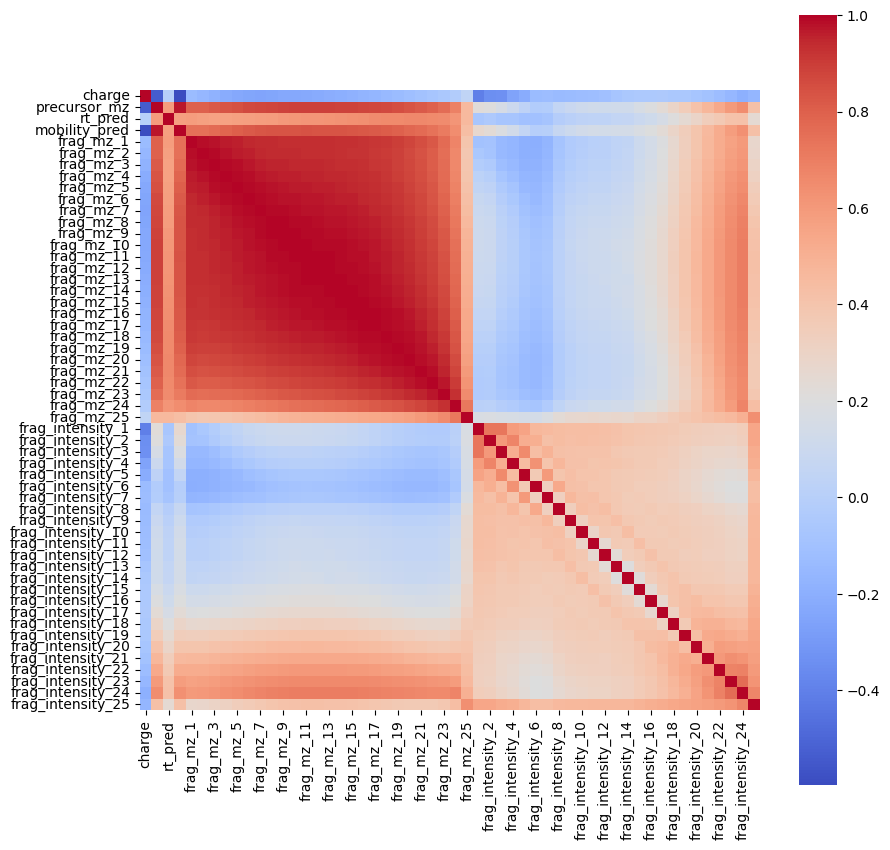

In [24]:
import seaborn as sns
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm', square=True)

In [25]:

cluster_counts = pd.Series(final_df['cluster']).value_counts()
print(cluster_counts)
len(cluster_counts)


cluster
-1      11392
 216     8784
 49      8782
 109     8777
 43      8774
        ...  
 185        2
 112        2
 103        2
 126        2
 171        2
Name: count, Length: 270, dtype: int64


270

In [26]:
# sample_df_with_cluster_labels = sample_df.copy()
# sample_df_with_cluster_labels['cluster'] = cluster_labels
# sample_df_with_cluster_labels

In [27]:

# tsne_result_with_cluster_labels = tsne_result.copy()
# tsne_result_with_cluster_labels['cluster'] = cluster_labels
# tsne_result_with_cluster_labels

In [28]:

# plot_tsne_results(tsne_result_with_cluster_labels, size_multiplier=1)
# plt.show()

<!-- ## Creating Siamese Pairs  -->

<!-- creating siamese pairs and load with a data loader  -->

### Creation Siamese pairs  and create data loaders for the model

In [29]:
def calculate_cosine_similarity(vec1, vec2):
    """
    Calculate cosine similarity between two vectors.
    
    Args:
        vec1 (torch.Tensor): First vector.
        vec2 (torch.Tensor): Second vector.
    
    Returns:
        float: Cosine similarity value.
    """
    # Convert rows to tensors and add batch dimension if needed
    vec1 = torch.tensor(vec1.values, dtype=torch.float32)
    vec2 = torch.tensor(vec2.values, dtype=torch.float32)
    
    return F.cosine_similarity(vec1, vec2, dim=0).item()

In [41]:

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

def create_siamese_pairs(df, encoded_features ,pairs_per_cluster=10, test_size=0.2):
    """
    Creates positive/negative pairs for Siamese network training from clustered data
    
    Args:
        df (pd.DataFrame): DataFrame with feature vectors and 'cluster' column
        pairs_per_cluster: Number of pairs to generate per cluster
        test_size: Proportion of data for validation
    
    Returns:
        (train_loader, val_loader): PyTorch DataLoader objects for training
    """
    # Validate input
    if 'cluster' not in df.columns:
        raise ValueError("DataFrame must contain 'cluster' column")
    
    features = df.drop('cluster', axis=1)
    clusters = df['cluster'].values
    unique_clusters = np.unique(clusters)
    
    # Storage for pairs and labels
    pairs = []
    labels = []
    similar_pairs = []
    dissimilar_pairs = []
    
    # Generate pairs for each cluster
    for cluster in unique_clusters:
        print(f"Processing cluster {cluster}...")
        # need to handle clusters of -1 (noise points in DBSCAN)
        if cluster == -1:
            continue
        # Get indices for current cluster
        cluster_indices = np.where(clusters == cluster)[0]
        
        # Skip clusters with < 2 samples
        if len(cluster_indices) < 2:
            continue
            
        # Positive pairs (same cluster)
        count = 0
        for i in range(pairs_per_cluster):
            count += 1
            if( count % 10 == 1):
                print(f"Processed {count} pairs for cluster {cluster}...")    
            
            # Randomly select two different samples from cluster
            similar_try_count = 0
            while True:
                if similar_try_count > 300:
                    print("Too many tries to find a similar pair")
                    break
                similar_try_count += 1
                idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
                cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
                if cos_sim > 0.9:
                    print(f"idx1: {idx1}, idx2: {idx2}, cos_sim: {cos_sim}")
                    pairs.append([encoded_features.iloc[idx1], encoded_features.iloc[idx2]])
                    similar_pairs.append([idx1, idx2])
                    labels.append(0)
                    break
                     
            # Negative pair (different cluster)
            dissimilar_try_count = 0
            while True:
                # Randomly select a sample from the different clusters
                if dissimilar_try_count > 300:
                    print("Too many tries to find a dissimilar pair")
                    break
                dissimilar_try_count += 1

                other_clusters = unique_clusters[unique_clusters != cluster]
                other_cluster = np.random.choice(other_clusters)
                other_indices = np.where(clusters == other_cluster)[0]
                idx3 = np.random.choice(other_indices)
                
                cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx3])
                if cos_sim < 0.1:
                    print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
                    pairs.append([encoded_features.iloc[idx1], encoded_features.iloc[idx3]])
                    dissimilar_pairs.append([idx1, idx3])
                    labels.append(1)
                    break
                
            # other_clusters = unique_clusters[unique_clusters != cluster]
            # other_cluster = np.random.choice(other_clusters)
            # other_indices = np.where(clusters == other_cluster)[0]
            # idx3 = np.random.choice(other_indices)
            # pairs.append([features[idx1], features[idx3]])
            # labels.append(1)
    
    # Convert to arrays
    pairs = np.array(pairs)
    labels = np.array(labels)
    
    print(f"Total pairs: {len(pairs)}, Total labels: {len(labels)}")
    print(f"Similar pairs: {len(similar_pairs)}, Dissimilar pairs: {len(dissimilar_pairs)}")
    
    
    # Shuffle and split
    indices = np.arange(len(labels))
    np.random.shuffle(indices)
    pairs = pairs[indices]
    labels = labels[indices]
    
    # Split into train/validation
    X_train, X_val, y_train, y_val = train_test_split(
        pairs, labels, test_size=test_size, stratify=labels
    )
    
    # Convert to PyTorch tensors
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    
    print("X_train shape:", X_train.shape)
    print("X_val shape:", X_val.shape)
    print("y_train shape:", y_train.shape)

    # Create DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=100)
    
    return train_loader, val_loader

# Usage example
# train_loader, val_loader = create_siamese_pairs(your_dataframe)



In [42]:
train_loader, val_loader = create_siamese_pairs(final_df, encoded_feature_vectors)

Processing cluster -1...
Processing cluster 0...
Processed 1 pairs for cluster 0...
Too many tries to find a similar pair
idx1: 954, idx3: 484077, cos_sim: 0.07926421612501144
Too many tries to find a similar pair
idx1: 753, idx3: 553111, cos_sim: 0.09990672767162323
Too many tries to find a similar pair
idx1: 8332, idx3: 401748, cos_sim: 0.09367360919713974
idx1: 9676, idx2: 9991, cos_sim: 0.9572389125823975
idx1: 9676, idx3: 95363, cos_sim: 0.0992690846323967
Too many tries to find a similar pair
idx1: 72, idx3: 379286, cos_sim: 0.09942827373743057
idx1: 7413, idx2: 6199, cos_sim: 0.9050530195236206
idx1: 7413, idx3: 485668, cos_sim: 0.08047465980052948
idx1: 6597, idx2: 7735, cos_sim: 0.9235252141952515
idx1: 6597, idx3: 74405, cos_sim: 0.094570592045784
Too many tries to find a similar pair
idx1: 9650, idx3: 437564, cos_sim: 0.06938864290714264
idx1: 2206, idx2: 4138, cos_sim: 0.921279788017273
idx1: 2206, idx3: 506279, cos_sim: 0.023057805374264717
Too many tries to find a similar

<!-- verify siamese pair -->


In [ ]:

# from sklearn.model_selection import train_test_split
# import torch.nn.functional as F
# from torch.utils.data import DataLoader, TensorDataset

# def create_siamese_pairs_temp(df, pairs_per_cluster=1000, test_size=0.2):
#     """
#     Creates positive/negative pairs for Siamese network training from clustered data
    
#     Args:
#         df (pd.DataFrame): DataFrame with feature vectors and 'cluster' column
#         pairs_per_cluster: Number of pairs to generate per cluster
#         test_size: Proportion of data for validation
    
#     Returns:
#         (train_loader, val_loader): PyTorch DataLoader objects for training
#     """
#     # Validate input
#     if 'cluster' not in df.columns:
#         raise ValueError("DataFrame must contain 'cluster' column")
    
#     features = df.drop('cluster', axis=1)
#     clusters = df['cluster'].values
#     unique_clusters = np.unique(clusters)
    
#     # Storage for pairs and labels
#     similarPairsIndices = []
#     dissimilarPairsIndices = []
#     pairs = []
#     labels = []
    
#     # Generate pairs for each cluster
#     for cluster in unique_clusters:
#         print(f"Processing cluster {cluster}...")
#         if cluster == -1:
#             continue
#         # Get indices for current cluster
#         cluster_indices = np.where(clusters == cluster)[0]
        
#         # Skip clusters with < 2 samples
#         if len(cluster_indices) < 2:
#             continue
            
#         # Positive pairs (same cluster)
#         count = 0 
#         for i in range(pairs_per_cluster):
#             if(count % 10 ==0):
#                 count += 1
#                 print(f"Processing cluster {cluster}...{count}")
#             # Randomly select two different samples from cluster
#             similar_try_count = 0
#             while True:
#                 if similar_try_count > 300:
#                     print("Too many tries to find a similar pair")
#                     break
#                 similar_try_count += 1
#                 idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
#                 cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
#                 if cos_sim > 0.9:
#                     print(f"idx1: {idx1}, idx2: {idx2}, cos_sim: {cos_sim}")
#                     pairs.append([features.iloc[idx1], features.iloc[idx2]])
#                     similarPairsIndices.append([idx1, idx2])
#                     labels.append(0)
#                     break
            
#             # idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
#             # cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
            
            
#             # pairs.append([features.iloc[idx1], features.iloc[idx2]])
#             # similarPairsIndices.append([idx1, idx2])
#             # labels.append(0)
            
#             # Negative pair (different cluster)
            
#             dissimilar_try_count = 0
#             while True:
                
#                 if dissimilar_try_count > 300:
#                     print("Too many tries to find a dissimilar pair")
#                     break
#                 dissimilar_try_count += 1

#                 other_clusters = unique_clusters[unique_clusters != cluster]
#                 other_cluster = np.random.choice(other_clusters)
#                 other_indices = np.where(clusters == other_cluster)[0]
#                 idx3 = np.random.choice(other_indices)
                
#                 cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx3])
#                 if cos_sim < 0.4:
#                     print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
#                     pairs.append([features.iloc[idx1], features.iloc[idx3]])
#                     dissimilarPairsIndices.append([idx1, idx3])
#                     labels.append(1)
#                     break
                
#             # other_clusters = unique_clusters[unique_clusters != cluster]
#             # other_cluster = np.random.choice(other_clusters)
#             # other_indices = np.where(clusters == other_cluster)[0]
#             # idx3 = np.random.choice(other_indices)
            
            
#             # print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
#             # pairs.append([features.iloc[idx1], features.iloc[idx3]])
#             # dissimilarPairsIndices.append([idx1, idx3])
#             # labels.append(1)
    
#     # Convert to arrays
#     pairs = np.array(pairs)
#     labels = np.array(labels)
    
#     # Shuffle and split
#     indices = np.arange(len(labels))
#     np.random.shuffle(indices)
#     pairs = pairs[indices]
#     labels = labels[indices]
    
#     return pairs, labels, similarPairsIndices, dissimilarPairsIndices
    
#     # # Split into train/validation
#     # X_train, X_val, y_train, y_val = train_test_split(
#     #     pairs, labels, test_size=test_size, stratify=labels
#     # )
    
#     # # Convert to PyTorch tensors
#     # X_train = torch.FloatTensor(X_train)
#     # X_val = torch.FloatTensor(X_val)
#     # y_train = torch.LongTensor(y_train)
#     # y_val = torch.LongTensor(y_val)
    
#     # # Create DataLoaders
#     # train_dataset = TensorDataset(X_train, y_train)
#     # val_dataset = TensorDataset(X_val, y_val)
    
#     # train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
#     # val_loader = DataLoader(val_dataset, batch_size=100)
    
#     # return train_loader, val_loader

# # Usage example
# # train_loader, val_loader = create_siamese_pairs(your_dataframe)


# pairs, labels, similar, dissimilar  = create_siamese_pairs_temp(sample_df_with_cluster_labels)

# len(similar) +len(dissimilar)
# len(similar) 
# len(dissimilar)

In [ ]:
# sample_df_with_cluster_labels.iloc[similar[1000]]

In [ ]:
# i = 2000
# plot_tsne_results(tsne_result_with_cluster_labels.iloc[similar[i]], size_multiplier=100)
# calculate_cosine_similarity(sample_df_with_cluster_labels.iloc[similar[i][0]], sample_df_with_cluster_labels.iloc[similar[i][1]])

<!-- # Loading the deconvoluted spectra using a dataloader -->

# Siamese Network Creation

## Define the model architecture

In [ ]:
# class SpectrumDataset(Dataset):
#     def __init__(self,mgf_file_path, max_peaks=200):
#         self.mgf_file_path = mgf_file_path
#         self.max_peaks = max_peaks
#         self.spectra = list(mgf.read(mgf_file_path))
        
#     def __len__(self):
#         return len(self.spectra)

#     def __getitem__(self, index):
#         spectrum = self.spectra[index]
#         mz_values = spectrum.get("m/z array", np.array([]))
#         intensity_values = spectrum.get("intensity array", np.array([]))
        
#         # normalize intensities
#         intensity_values = intensity_values / np.max(intensity_values) if intensity_values.size else intensity_values

#         return torch.tensor(np.stack(mz_values,intensity_values), axis=1)

In [43]:
class SiamesNetwork(nn.Module):
    def __init__(self, input_dim=482):
        super().__init__()
        
        # Feature extractors
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 16, 3),
            nn.BatchNorm1d(16),
            nn.SELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 3),
            nn.SELU(),
            nn.AdaptiveAvgPool1d(10)
        )
        
        self.fc_block = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.SELU(),
            nn.Dropout(0.3)
        )
        
        # Fusion layer
        self.final_fc = nn.Linear(32*10 + 32, 30)

    def forward_once(self, x):
        # Spectral features
        conv_out = self.conv_block(x.unsqueeze(1))  # [batch,32,10]
        conv_out = conv_out.flatten(1)  # [batch,320]
        
        # Precursor features
        fc_out = self.fc_block(x)  # [batch,32]
        
        # Concatenate
        combined = torch.cat([conv_out, fc_out], dim=1)
        return self.final_fc(combined)

    
    def forward(self, x1, x2):
        output1 = self.forward_once(x1)
        output2 = self.forward_once(x2)
        return output1, output2


In [69]:
class SiameseNetwork2(nn.Module):
    def __init__(self):
        super(SiameseNetwork2, self).__init__()

        self.fc1_1 = nn.Linear(7, 32)
        self.fc1_2 = nn.Linear(32, 5)

        self.cnn1 = nn.Conv1d(1, 30, kernel_size=3)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.cnn2 = nn.Conv1d(30, 30, kernel_size=3)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.fc2 = None  # Will be initialized in first forward pass

    def forward_once(self, preInfo, fragInfo):
        pre = F.selu(self.fc1_1(preInfo))
        pre = F.selu(self.fc1_2(pre))

        fragInfo = fragInfo.unsqueeze(1)
        frag = F.selu(self.cnn1(fragInfo))
        frag = self.pool1(frag)
        frag = F.selu(self.cnn2(frag))
        frag = self.pool2(frag)
        frag = frag.view(frag.size(0), -1)

        combined = torch.cat((pre, frag), dim=1)

        if self.fc2 is None:
            # Lazily initialize fc2 with correct input size
            self.fc2 = nn.Linear(combined.size(1), 32).to(combined.device)

        out = self.fc2(combined)
        return out

    def forward(self, spectrum01, spectrum02):
        input1_pre = spectrum01[:, :7]
        input1_frag = spectrum01[:, 7:]

        input2_pre = spectrum02[:, :7]
        input2_frag = spectrum02[:, 7:]

        out1 = self.forward_once(input1_pre, input1_frag)
        out2 = self.forward_once(input2_pre, input2_frag)

        return out1, out2


In [60]:
# Define the Contrastive Loss Function
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # # Calculate the euclidian distance and calculate the contrastive loss
        # euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)

        # loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2) +
        #                                 (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        # return loss_contrastive
        
        euclidean_distance = F.pairwise_distance(output1, output2)
        euclidean_distance = euclidean_distance.double()
        #print(euclidean_distance)
        label = label.double()
        loss_contrastive = torch.mean(label * euclidean_distance + (1-label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))

        return loss_contrastive



In [36]:
# net =SiamesNetwork()
# lossFunc = ContrastiveLoss()
# optimzer = optim.Adam(net.parameters(), lr = 0.0005)
for batch_idx, (pairs, labels) in enumerate(train_loader):
    print(pairs.shape)
    x1 = pairs[:, 0, :]  # Shape: [batch_size, input_dim]
    x2 = pairs[:, 1, :]  # Shape: [batch_size, input_dim]
    print(x1.shape)
    print(x1.size(0))
    x11 = x1.view(x1.size(0), -1)
    print(x11.shape)
    

    break

torch.Size([100, 2, 482])
torch.Size([100, 482])
100
torch.Size([100, 482])


## Tranning the model

In [ ]:
if __name__ == "__main__":
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize model and move to device
    model = SiameseNetwork2().to(device)
    criterion = ContrastiveLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    
    # Add learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        patience=5, 
        factor=0.5, 
        verbose=True
    )
    
    # Training loop
    num_epochs = 200
    best_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for batch_idx, (pairs, labels) in enumerate(train_loader):
            # Move data to device
            x1 = pairs[:, 0, :].to(device)
            x2 = pairs[:, 1, :].to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            output1, output2 = model(x1, x2)
            loss = criterion(output1, output2, labels)
            loss.backward()
            
            # Add gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            epoch_loss += loss.item()
            
            if batch_idx % 79 == 0:
                print(f"Epoch {epoch+1} | Batch {batch_idx} | Loss: {loss.item():.4f}")
        
        avg_epoch_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_epoch_loss:.4f} | LR: {optimizer.param_grouzps[0]['lr']:.2e}")
        
        # Update learning rate based on epoch loss
        scheduler.step(avg_epoch_loss)
        
        # Save best model
        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            torch.save(model.state_dict(), "best_model.pth")
            print(f"Saved new best model with loss: {best_loss:.4f}")


Epoch 1 | Batch 0 | Loss: 0.5026
Epoch 1/200 | Loss: 0.4002 | LR: 1.00e-03
Saved new best model with loss: 0.4002
Epoch 2 | Batch 0 | Loss: 0.3949
Epoch 2/200 | Loss: 0.3822 | LR: 1.00e-03
Saved new best model with loss: 0.3822
Epoch 3 | Batch 0 | Loss: 0.3764
Epoch 3/200 | Loss: 0.3765 | LR: 1.00e-03
Saved new best model with loss: 0.3765
Epoch 4 | Batch 0 | Loss: 0.3836
Epoch 4/200 | Loss: 0.3716 | LR: 1.00e-03
Saved new best model with loss: 0.3716
Epoch 5 | Batch 0 | Loss: 0.3665
Epoch 5/200 | Loss: 0.3693 | LR: 1.00e-03
Saved new best model with loss: 0.3693
Epoch 6 | Batch 0 | Loss: 0.3899
Epoch 6/200 | Loss: 0.3672 | LR: 1.00e-03
Saved new best model with loss: 0.3672
Epoch 7 | Batch 0 | Loss: 0.3930
Epoch 7/200 | Loss: 0.3658 | LR: 1.00e-03
Saved new best model with loss: 0.3658
Epoch 8 | Batch 0 | Loss: 0.3605
Epoch 8/200 | Loss: 0.3650 | LR: 1.00e-03
Saved new best model with loss: 0.3650
Epoch 9 | Batch 0 | Loss: 0.3621
Epoch 9/200 | Loss: 0.3634 | LR: 1.00e-03
Saved new bes

## Model evaluation

In [73]:
import torch
import torch.nn.functional as F

def evaluate_model(model, test_loader, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for pairs, labels in test_loader:
            x1 = pairs[:, 0, :]
            x2 = pairs[:, 1, :]

            output1, output2 = model(x1, x2)

            # Cosine similarity
            cos_sim = F.cosine_similarity(output1, output2)
            

            # Compute loss
            loss = criterion(output1, output2, labels)
            total_loss += loss.item()

            # Apply prediction logic
            predicted = torch.full_like(labels, -1.0)  # initialize with -1 (undecided)

            predicted[cos_sim > 0.8] = 0  # predict similar
            predicted[cos_sim < 0.4] = 1  # predict dissimilar

            # Only count predictions that are decided (not -1)
            mask = predicted != -1
            # correct += (predicted[mask] == labels[mask]).sum().item()
            print(mask)
            correct += (predicted == labels).sum().item()
            total += mask.sum().item()

    accuracy = 100 * correct / total if total > 0 else 0.0
    avg_loss = total_loss / len(test_loader)

    print(f"Total pairs: {len(test_loader.dataset)}, Correct: {correct}, Total: {total}")
    print(f"Evaluation - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}% (on {total} confident predictions)")

# Example usage (assuming you have test_loader and model trained)
if __name__ == "__main__":
    evaluate_model(model, val_loader, criterion)


tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])
tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
       

In [ ]:
for batch_idx, (pairs, labels) in enumerate(val_loader):
    model.eval()
    print("Batch index:", batch_idx) if batch_idx % 79 == 0 else None
     # Split pairs into two inputs
    x1 = pairs[:, 0, :]  # Shape: [batch_size, input_dim]
    x2 = pairs[:, 1, :]  # Shape: [batch_size, input_dim]
    print(labels)
    output1, output2 = model(x1, x2)

    # Cosine similarity
    cos_sim = F.cosine_similarity(output1, output2)
    print("cos_sim:", cos_sim)  
    

    # Compute loss
    loss = criterion(output1, output2, labels)
    print(f"Loss: {loss.item()}")
    

    break
    
        

Batch index: 0
tensor([0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
        1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
        1, 0, 0, 1])
cos_sim: tensor([1.0000, 0.9921, 0.9998, 0.9904, 0.9905, 0.9915, 0.9911, 1.0000, 0.9917,
        0.9940, 0.9998, 0.9878, 0.9999, 0.9944, 0.9999, 1.0000, 0.9999, 0.9999,
        0.9970, 0.9924, 1.0000, 0.9996, 0.9999, 0.9981, 1.0000, 0.9865, 0.9888,
        0.9997, 0.9909, 0.9883, 0.9965, 0.9960, 0.9977, 0.9913, 0.9908, 0.9884,
        0.9953, 0.9926, 0.9964, 0.9959, 0.9907, 0.9983, 0.9997, 0.9915, 0.9997,
        1.0000, 0.9968, 1.0000, 0.9915, 1.0000, 0.9961, 1.0000, 1.0000, 0.9998,
        1.0000, 0.9891, 0.9922, 0.9918, 0.9999, 0.9932, 1.0000, 0.9924, 1.0000,
        1.0000, 0.9920, 0.9998, 0.9997, 0.9916, 0.9997, 0.9894, 1.0000, 1.0

In [ ]:
# torch.save(model.state_dict(), "./trained_models/siamese_02")